## 节点的并行执行
并行执行读取到的快照是对立的，如下 node2、node3读取了node1的快照。
node4 上游有node2和node3, 在上有更新的属性中必须 包含reducer，让下游知道怎么合并状态，否则会报错

In [7]:
from operator import add
from time import sleep
from typing import TypedDict, Annotated

from langgraph.graph import StateGraph, START, END


# 1、定义状态
class OverAllState(TypedDict):
    logs: Annotated[list[str], add]
    # 如果出现并行节点，同时更新状态，往下游节点传递的时候，必须有reducer
    id: Annotated[str, add]


# 2、定义节点
def node_1(state: OverAllState) -> OverAllState:
    # 调用状态
    for k, v in state.items():
        print(f"1k:{k}, v:{v}")
    return {
        "logs": ["node_1 运行完毕"],
        "id":"node_1"
    }


def node_2(state: OverAllState) -> OverAllState:
    # 调用状态
    for k, v in state.items():
        print(f"2k:{k}, v:{v}")
    return {
        "logs": ["node_2 运行完毕"],
        "id":"node_2"
    }


def node_3(state: OverAllState) -> OverAllState:
    sleep(1)
    # 调用状态
    for k, v in state.items():
        print(f"3k:{k}, v:{v}")
    return {
        "logs": ["node_3 运行完毕"],
        "id":"node_3"
    }


def node_4(state: OverAllState) -> OverAllState:
    sleep(2)
    # 调用状态
    for k, v in state.items():
        print(f"4k:{k}, v:{v}")
    return {
        "logs": ["node_4 运行完毕"],
        "id":"node_4"
    }


# 3、创建图
builder = StateGraph(state_schema=OverAllState)
builder.add_node("node_1", node_1)
builder.add_node("node_2", node_2)
builder.add_node("node_3", node_3)
builder.add_node("node_4", node_4)

builder.add_edge(START, "node_1")
builder.add_edge("node_1", "node_2")
builder.add_edge("node_1", "node_3")
builder.add_edge("node_2", "node_4")
builder.add_edge("node_3", "node_4")
builder.add_edge("node_4", END)

graph = builder.compile()
result = graph.invoke({"logs": ["start"], "id": "start"})
print('=' * 30, '-> result <-', '=' * 30)
print(result)


1k:logs, v:['start']
1k:id, v:start
2k:logs, v:['start', 'node_1 运行完毕']
2k:id, v:startnode_1
3k:logs, v:['start', 'node_1 运行完毕']
3k:id, v:startnode_1
4k:logs, v:['start', 'node_1 运行完毕', 'node_2 运行完毕', 'node_3 运行完毕']
4k:id, v:startnode_1node_2node_3
============================== -> result <- ==============================
{'logs': ['start', 'node_1 运行完毕', 'node_2 运行完毕', 'node_3 运行完毕', 'node_4 运行完毕'], 'id': 'startnode_1node_2node_3node_4'}


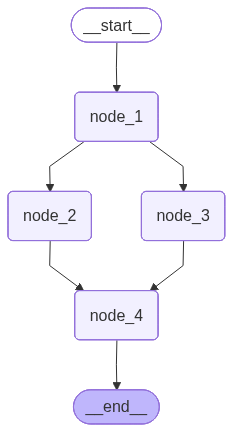

In [8]:

from IPython.display import Image, display

# 获取图的mermaid代码，可以直接在md中渲染
raw_mermaid = graph.get_graph().draw_mermaid()
# get_graph 获取图，draw_mermaid_png 获取图mermaid代码
png_bytes = graph.get_graph().draw_mermaid_png()
# 转换为图片
png = Image(png_bytes)
display(png)